# Getting masks from mannually labeled images

In [1]:
import numpy as np
from PIL import Image
from scipy import ndimage
from skimage.measure import regionprops
import os

Image.MAX_IMAGE_PIXELS = None

def get_masks_old(input_dir, outpur_dir):
    images = os.listdir(input_dir)
    for image in images:
        # Open image and make RGB and HSV versions
        RGBim = Image.open(input_dir + image)
        HSVim = RGBim.convert('HSV')

        # Make numpy versions
        RGBna = np.array(RGBim)
        HSVna = np.array(HSVim)

        # Extract Hue
        H = HSVna[:,:,0]

        # Find all green pixels, i.e. where 100 < Hue < 140
        lo,hi = 100,140
        # Rescale to 0-255, rather than 0-360 because we are using uint8
        lo = int((lo * 255) / 360)
        hi = int((hi * 255) / 360)
        green = np.where((H>lo) & (H<hi))
        not_green = np.where((H<=lo) | (H>=hi))

        # Make all green pixels black in original image
        RGBna[green] = [0,0,0]
        RGBna[not_green] = [255,255,255]

        count = green[0].size
        print("Pixels matched: {}".format(count))

        labeled, nr_objects = ndimage.label(RGBna != [255,255,255]) 
        props = regionprops(labeled)

        print('Number of objects: ' + str(len(props)))
        new_mask = np.invert(np.copy(RGBna))

        for prop in range(len(props)):
            if props[prop].area > 100:
                [X, Y, W, H, a, b] = props[prop].bbox

                new_mask[X:H, Y:a] = props[prop].image_convex.astype(np.uint8)*255

        Image.fromarray(new_mask).save(outpur_dir + image.split(".")[0] + ".png", "PNG", quality=100)

In [2]:

base_path = "C:\\Users\\Igor\\tumor_regions_segmentation\\datasets\\MANDIBULA\\"
training_images_path = base_path + "training\\labelled_images\\png\\"
training_masks_path = base_path + "training\\annotations\\"

testing_images_path = base_path + "testing\\labelled_images\\png\\"
testing_masks_path = base_path + "testing\\annotations\\"

In [3]:
import matplotlib.pyplot as plt
from PIL import ImageFilter

def fill_contours(arr):
    return np.maximum.accumulate(arr,1) & np.maximum.accumulate(arr[:,::-1],1)[:,::-1]

# Seleciona pixels verdes
def get_masks_1(path_to_image):
    # Open image and make RGB and HSV versions
    RGBim = Image.open(path_to_image)
    HSVim = RGBim.convert('HSV')
    # Make numpy versions
    RGBna = np.array(RGBim)
    HSVna = np.array(HSVim)
    # Extract Hue
    H = HSVna[:,:,0]
    # Find all green pixels, i.e. where 100 < Hue < 140
    lo,hi = 90,150
    # Rescale to 0-255, rather than 0-360 because we are using uint8
    lo = int((lo * 255) / 360)
    hi = int((hi * 255) / 360)
    green = np.where((H>lo) & (H<hi))
    not_green = np.where((H<=lo) | (H>=hi))
    # Make all green pixels black in original image
    RGBna[green] = [0,0,0]
    RGBna[not_green] = [255,255,255]
    #plt.imshow(RGBna)#Image.fromarray(RGBna).show()

    return np.invert(RGBna)
    
# dilation
def dilate(RGBna, filter_size):
    dilation_img = Image.fromarray(RGBna).filter(ImageFilter.MaxFilter(filter_size))
    return np.array(dilation_img)

# dilation
def erode(RGBna, filter_size):
    erosion_img = Image.fromarray(RGBna).filter(ImageFilter.MinFilter(filter_size))
    return np.array(erosion_img)

# Remove ruídos  
def get_masks_2(RGBna, mean_props_area):
    labeled, _ = ndimage.label(RGBna != [0,0,0]) 
    props = regionprops(labeled)

    new_mask = np.copy(RGBna)
    
    for prop in range(len(props)):
        if props[prop].area > mean_props_area:
            continue
        else:
            [X, Y, _, H, a, b] = props[prop].bbox
            new_mask[X:H, Y:a] = props[prop].image_filled.astype(np.uint8)*0
       
            
    #plt.imshow(new_mask)#Image.fromarray(new_mask).show()
    return new_mask

def get_mean_props_area(RGBna):
    return int(RGBna.shape[0]/30)**2

# Preenche contornos  
def get_masks_3(RGBna, mean_props_area):
    labeled, nr_objects = ndimage.label(RGBna != [0,0,0]) 
    print(nr_objects)
    props = regionprops(labeled)
    print(len(props))

    new_mask = np.copy(RGBna)

    for prop in range(len(props)):
        #if props[prop].area > mean_props_area:
        #    continue
        [X, Y, W, H, a, b] = props[prop].bbox
        plt.imshow(props[prop].image_filled.astype(np.uint8)*255)
        #new_mask[X:H, Y:a] = fill_contours(props[prop].image_filled.astype(np.uint8)*255)#props[prop].image_filled.astype(np.uint8)*255
        
            
    #plt.imshow(new_mask)#Image.fromarray(new_mask).show()
    return new_mask

def get_masks(input_dir, output_dir):
    images = os.listdir(input_dir)
    for image in images:
        print(input_dir + image)
        step_1 = get_masks_1(input_dir + image)
        #mean = get_mean_props_area(step_1)
        #step_2 = get_masks_2(step_1, mean)
        #step_3 = get_masks_3(step_2)
        Image.fromarray(step_3).save(output_dir + image.split(".")[0] + ".png", "PNG", quality=100)

def get_image_mask(input_dir, output_dir, image):
    step_1 = get_masks_1(input_dir + image)
    mean = get_mean_props_area(step_1)
    step_2 = get_masks_2(step_1, mean)
    step_3 = get_masks_3(step_2, mean)
    Image.fromarray(step_3).save(output_dir + image.split(".")[0] + ".png", "PNG", quality=100)



In [14]:
image_name = "Ir20_63_L2"

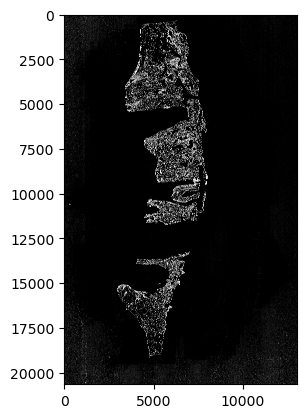

In [ ]:
# TRAINING
x = get_masks_1(training_images_path + image_name + ".png")
#Image.fromarray(x).save("x.png", "PNG", quality=100)
plt.imshow(x)

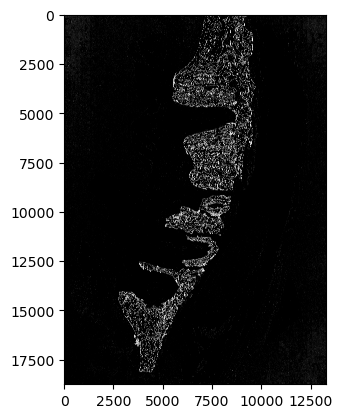

In [15]:
# testing
x = get_masks_1(testing_images_path + image_name + ".png")
#Image.fromarray(x).save("x.png", "PNG", quality=100)
plt.imshow(x)

In [16]:
x_erode = x

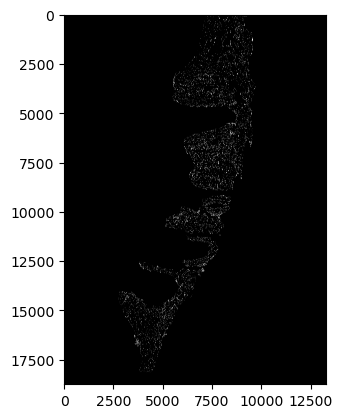

In [17]:
x_erode = erode(x_erode, 5)
plt.imshow(x_erode)

In [18]:
x_dilate = x_erode

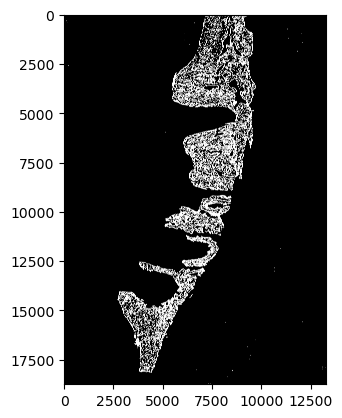

In [19]:
x_dilate = dilate(x_dilate, 21)
plt.imshow(x_dilate)

In [20]:
Image.fromarray(x_dilate).save("_to_paint_" + image_name + ".png", "PNG", quality=100)

In [295]:
labeled, nr_objects = ndimage.label(x_dilate != [0,0,0])
print(nr_objects)

3098


In [12]:
x2 = x_dilate

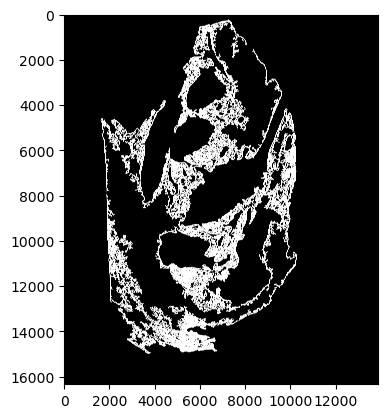

In [13]:
y = get_masks_2(x2, get_mean_props_area(x2))
#Image.fromarray(y).save("y.png", "PNG", quality=100)
plt.imshow(y)

21
21


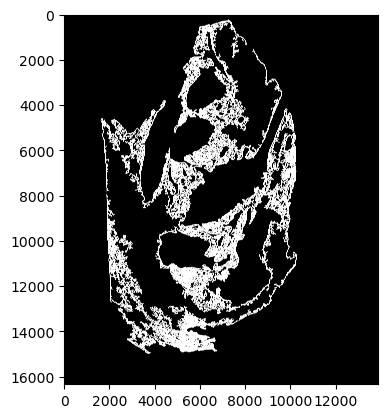

In [14]:
z = get_masks_3(y, get_mean_props_area(x2))
#Image.fromarray(z).save("z.png", "PNG", quality=100)
plt.imshow(z)

In [ ]:
z2 = get_masks_2(z, int(z.shape[0]/5)**2)
#plt.imshow(z2)

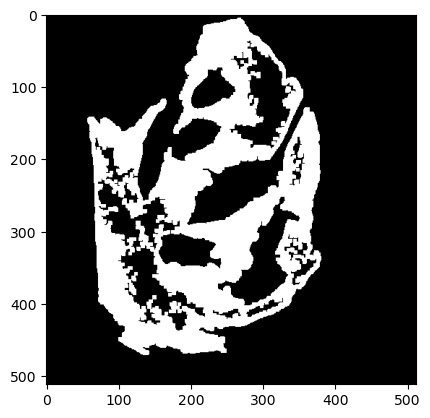

In [271]:
z3 = np.invert(z2)
labeled, nr_objects = ndimage.label(z3 != [0,0,0])
props = regionprops(labeled)

new_mask = np.copy(z2)
    
for prop in range(len(props)):
    if prop == 0:
        continue
    if props[prop].area > get_mean_props_area(z):
        continue
    [X, Y, _, H, a, b] = props[prop].bbox
    new_mask[X:H, Y:a] = new_mask[X:H, Y:a] ^ props[prop].image_filled.astype(np.uint8)*255
       
            
plt.imshow(new_mask)#Image.fromarray(new_mask).show()
#zfinal = np.invert(props[0].image_filled.astype(np.uint8)*255)
#plt.imshow(props[0].image.astype(np.uint8)*255)
Image.fromarray(new_mask).save("z.png", "PNG", quality=100)

In [20]:

## Make numpy versions
#step_0 = np.array(Image.open(training_images_path + "301.jpg"))  
#step_1 = get_masks_1(training_images_path + "301.jpg")
#
#mean = get_mean_props_area(step_1)
#
#step_2 = get_masks_2(step_1, mean)
#step_3 = get_masks_3(step_2, mean)
#
#if not os.path.exists(training_masks_path):
#    os.mkdir(training_masks_path)
#    
#if not os.path.exists(testing_masks_path):
#    os.mkdir(testing_masks_path)

In [30]:
#plt.figure()
##subplot(r,c) provide the no. of rows and columns
#f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2)
#
## use the created array to output your multiple images. In this case I have stacked 4 images vertically
#ax1.imshow(step_0[6800:8000,2700:5000])
##ax1.set_title('(a)')
#ax1.axis('off')
#ax1.savefig('C:\\\Igor\\output1.png', dpi=300)
#
#ax2.imshow(step_1[6800:8000,2700:5000])
##ax2.set_title('(b)')
#ax2.axis('off')
#ax2.savefig('C:\\\Igor\\output2.png', dpi=300)
#
#ax3.imshow(step_2[6800:8000,2700:5000])
##ax3.set_title('(c)')
#ax3.axis('off')
#ax3.savefig('C:\\\Igor\\output3.png', dpi=300)
#
#ax4.imshow(step_3[6800:8000,2700:5000])
##ax4.set_title('(d)')
#ax4.axis('off')
#ax4.savefig('C:\\\Igor\\output4.png', dpi=300)
#
#plt.tight_layout()
#plt.savefig('C:\\\Igor\\output.png', dpi=300)

In [28]:
# Get training masks

if not os.path.exists(training_masks_path):
    os.mkdir(training_masks_path)

get_masks(training_images_path, training_masks_path)


C:\Users\Igor\tumor_regions_segmentation\datasets\MANDIBULA\training\labelled_images\png\Ir15_20_L2.png


In [ ]:
# Get test masks

if not os.path.exists(testing_masks_path):
    os.mkdir(testing_masks_path)

get_masks(testing_images_path, testing_masks_path)

c:\Users\Igor\anaconda3\envs\dali\lib\site-packages\PIL\Image.py:3167: DecompressionBombWarning: Image size (94459539 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
c:\Users\Igor\anaconda3\envs\dali\lib\site-packages\PIL\Image.py:3167: DecompressionBombWarning: Image size (93092000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


In [21]:
def make_square(im, min_size=256, fill_color=(0, 0, 0, 255)):
    x, y = im.size
    size = max(min_size, x, y)
    new_im = Image.new('RGBA', (size, size), fill_color)
    if size == y:
        new_im.paste(im, (int((size - x)/2), 0))
    else:
        new_im.paste(im, (0, int((size - y)/2)))
    return new_im

def resize_images(input_dir, outpur_dir, fill_color='black'):
    images = os.listdir(input_dir)

    for image in images:
        RGBim = Image.open(input_dir + image)
        if fill_color == 'black':
            resized = make_square(RGBim)
        else:
            resized = make_square(RGBim, fill_color=(255,255,255,255))
            
        resized.save(outpur_dir + image.split(".")[0] + ".png", "PNG", quality=100)
        
        if image[-3:] != "png":
            os.remove(input_dir + image)

In [22]:
# Resizing training masks
resize_images(training_masks_path, training_masks_path)

# Resizing training bones images
training_wsi_path = base_path + "training\\wsi\\png\\"
resized_training_wsi_path = base_path + "training\\wsi\\png\\"
resize_images(training_wsi_path, resized_training_wsi_path, fill_color='white')

In [23]:
# Resizing testing masks
resize_images(testing_masks_path, testing_masks_path)

# Resizing WSI images
testing_wsi_path = base_path + "testing\\wsi\\png\\"
resized_testing_wsi_path = base_path + "testing\\wsi\\png\\"
resize_images(testing_wsi_path, resized_testing_wsi_path, fill_color='white')

In [24]:
# Resizing WSI images
testing_wsi_path = base_path + "testing\\wsi\\png\\"
resized_testing_wsi_path = base_path + "testing\\wsi\\png\\"
resize_images(testing_wsi_path, resized_testing_wsi_path, fill_color='white')